In [2]:
import pandas as pd
from plotnine import *
import numpy as np
from vpop_calibration.api import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
df = pd.read_csv("../../../examples/benchmarking/Mavoglurant/Mavoglurant_Dataset.csv")


obs_df = (
    df.loc[df["EVID"] == 0]
    .rename(columns={"ID": "id", "TIME": "time", "DV": "value", "DOSE": "Dose"})[
        ["id", "time", "value", "Dose", "WT"]
    ]
    .astype({"value": "float"})
)
obs_df["time"] = obs_df["time"].apply(lambda t: t * 60 * 60)
obs_df["value"] = obs_df["value"].apply(lambda t: np.log(t))
obs_df["output_name"] = "logC15"
obs_df["protocol_arm"] = "identity"
display(df.head())
display(obs_df.head())

,ID,CMT,EVID,MDV,DV,AMT,TIME,DOSE,OCC,RATE,AGE,SEX,WT,HT,occ
0,793,Venous_Blood,1,1,0.0,25.0,0.000,25.0,1,75,42,1,94.3,1.769997,1
1,793,C15,0,0,491.0,0.0,0.200,25.0,1,0,42,1,94.3,1.769997,1
2,793,C15,0,0,605.0,0.0,0.250,25.0,1,0,42,1,94.3,1.769997,1
3,793,C15,0,0,556.0,0.0,0.367,25.0,1,0,42,1,94.3,1.769997,1
4,793,C15,0,0,310.0,0.0,0.533,25.0,1,0,42,1,94.3,1.769997,1


,id,time,value,Dose,WT,output_name,protocol_arm
1,793,720.0,6.196444,25.0,94.3,logC15,identity
2,793,900.0,6.405228,25.0,94.3,logC15,identity
3,793,1321.2,6.320768,25.0,94.3,logC15,identity
4,793,1918.8,5.736572,25.0,94.3,logC15,identity
5,793,2520.0,5.468060,25.0,94.3,logC15,identity


In [4]:
struct_model = StructuralSbml(
    model_path="./CM.xml",
    inputs=["KbBR", "CLint", "KbAD", "KbBO", "KbRB", "WT", "Dose"],
    outputs=["logC15"],
)

struct_model.rr.setIntegrator("cvode")
integ = struct_model.rr.integrator
integ.setValue("stiff", True)
integ.setValue("relative_tolerance", 1e-6)
integ.setValue("absolute_tolerance", 1e-6)
integ.setValue("initial_time_step", 1e-6)

In [5]:
input_params = {
    "model_intrinsic": {
        "KbBR": {"prior": np.exp(1.1)},
        "KbBO": {"prior": np.exp(0.03)},
        "KbAD": {"prior": np.exp(2)},
        "KbRB": {"prior": np.exp(0.3)},
    },
    "pdu": {
        "CLint": {"prior": np.exp(7.6), "prior_omega": 1},
    },
    "pdk": {"WT", "Dose"},
    "error_model": {
        "logC15": {"error_type": "additive", "sigma": 2},
    },
}
config = Config(
    saem=SaemConfigDict(
        nb_iter_burnin=50,
        nb_iter_learning=150,
        nb_iter_smoothing=100,
        plot_frames=5,
    ),
    nlme=NlmeConfigDict(nb_chains=2),
)
nlme_model = NlmeModel(
    df=obs_df, input_params=input_params, structural_model=struct_model, config=config
)

  0%|          | 0/300 [00:00<?, ?it/s]

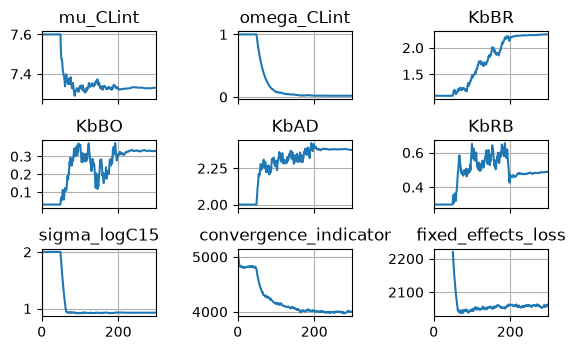

In [6]:
nlme_model.optimizer.run()

Sampling already started, adding 5 new samples.


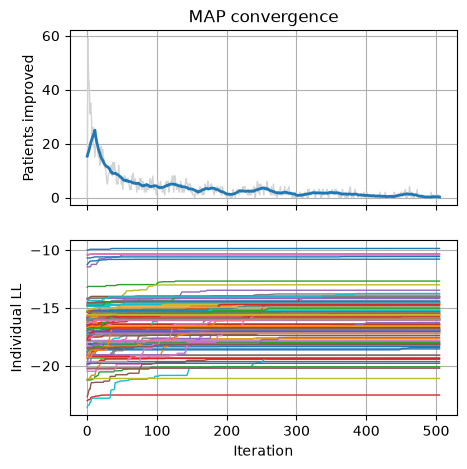

  0%|          | 0/5 [00:00<?, ?it/s]

In [10]:
nlme_model.diagnostics.sample_conditional_distribution(nb_samples=5)

In [8]:
nlme_model.diagnostics.sampler.map_parameters_df.to_csv("Sbml_map.csv", index=False)

In [9]:
# nlme_model.diagnostics.sample_conditional_distribution(400)
nlme_model.diagnostics.compute_vpc(quantiles=[0.05, 0.5, 0.95])
vpc_py = nlme_model.diagnostics.vpc
vpc_py["model"] = "Sbml"
vpc_py.to_csv("Sbml_VPC.csv", index=False)
print(vpc_py.head(12))

    bin  quantile     q_obs  pred_median  pred_lower  pred_upper  bin_center  \
0     0      0.05  3.645969     3.912389    3.890242    3.930578      2700.0   
1     0      0.50  5.438079     5.552791    5.542335    5.569003      2700.0   
2     0      0.95  6.572560     9.499454    9.499454    9.499454      2700.0   
3     1      0.05  2.609329     2.729856    2.693213    2.765728     26429.4   
4     1      0.50  3.453152     3.342125    3.325473    3.358465     26429.4   
5     1      0.95  4.318117     3.981117    3.956103    4.013242     26429.4   
6     2      0.05  2.160535     2.275319    2.237982    2.312577     44100.0   
7     2      0.50  2.901406     2.753171    2.709017    2.781368     44100.0   
8     2      0.95  3.865349     3.294696    3.257748    3.330940     44100.0   
9     5      0.05  1.062357     1.484858    1.439936    1.521837     87120.0   
10    5      0.50  1.967112     2.004570    1.973554    2.033800     87120.0   
11    5      0.95  3.143655     2.562113